In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tbats import TBATS, BATS
import numpy as np
import pickle

# %% load and prepare the sample data
df = pd.read_csv("AEP_hourly_full.csv", sep=",")
df = df[(df.Datetime >= "2011-02-01 00:00:00") & (df.Datetime < "2011-05-21 00:00:00")]
df = df.rename(columns={"AEP_MW": "energy"})
df.index = pd.to_datetime(df.Datetime, dayfirst=True, infer_datetime_format=True)
df = df.sort_index()

C:\Users\mrosk\AppData\Local\Temp\ipykernel_2628\3638612443.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df.index = pd.to_datetime(df.Datetime, dayfirst=True, infer_datetime_format=True)
C:\Users\mrosk\AppData\Local\Temp\ipykernel_2628\3638612443.py:12: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df.index = pd.to_datetime(df.Datetime, dayfirst=True, infer_datetime_format=True)


In [6]:
X_train = df.iloc[:-(20*24)].energy
X_test = df.iloc[-(20*24) :].energy

In [4]:
bats_estimator = BATS(
    seasonal_periods=[24, 169],
    use_arma_errors=True,  # consider ARMA
    use_box_cox=True,  # consider Box-Cox Trans.
    use_damped_trend=False,  # no damping
    use_trend=False,  # no trend
    n_jobs=1,  # number of parallel jobs
)

In [5]:
df

,Datetime,energy
Datetime,,
2011-02-01 00:00:00,2011-02-01 00:00:00,17479.0
2011-02-01 01:00:00,2011-02-01 01:00:00,16870.0
2011-02-01 02:00:00,2011-02-01 02:00:00,16473.0
2011-02-01 03:00:00,2011-02-01 03:00:00,16411.0
2011-02-01 04:00:00,2011-02-01 04:00:00,16346.0
...,...,...
2011-05-20 19:00:00,2011-05-20 19:00:00,14812.0
2011-05-20 20:00:00,2011-05-20 20:00:00,14531.0
2011-05-20 21:00:00,2011-05-20 21:00:00,14665.0


In [7]:
bats_model = bats_estimator.fit(X_train)

In [8]:
with open("bats_model.pkl",'wb') as f:
    pickle.dump(bats_model,f)

# %% load object from file
# with open('bats_model.pkl', 'rb') as f:
#     bats_model = pickle.load(f)

In [9]:
print(bats_model.summary())

Use Box-Cox: True
Use trend: False
Use damped trend: False
Seasonal periods: [ 24 169]
ARMA errors (p, q): (0, 0)
Box-Cox Lambda 0.548482
Smoothing (Alpha): 1.319544
Seasonal Parameters (Gamma): [ 0.14216858 -0.00888503]
AR coefficients []
MA coefficients []
Seed vector [ 3.61735433e+02 -3.42428362e+00  6.66981751e+00  1.38547572e+01
  1.56667164e+01  9.93194137e+00  3.91410816e+00  2.05201386e+00
  1.37506708e+00  2.39805025e+00  4.72746032e+00  6.93498278e+00
  8.57616101e+00  1.02776439e+01  1.16124772e+01  1.20149592e+01
  1.10432859e+01  6.33809829e+00 -4.93825861e+00 -1.70383114e+01
 -2.29146937e+01 -2.40518012e+01 -2.28682945e+01 -1.94711712e+01
 -1.25848903e+01  1.01691903e+01  9.01837570e+00  8.14505932e+00
  6.50886666e+00  4.67355646e+00  2.86587361e+00  1.12983430e+00
 -4.98911586e-01 -1.07928903e+00 -1.06831435e+00 -1.26699911e+00
 -8.77362434e-01 -8.02019961e-01  6.22866228e-01  1.75891343e+00
  2.76170310e+00  3.70637478e+00  4.50430355e+00  3.73074975e+00
  3.23199046e+

In [10]:
bats_fit = pd.DataFrame(
    bats_model.y_hat, columns=["bats_fit"], index=df.index[: len(X_train)]
)
df["bats_fit"] = bats_fit



In [11]:
bats_fit

,bats_fit
Datetime,
2011-02-01 00:00:00,15609.741092
2011-02-01 01:00:00,17531.766428
2011-02-01 02:00:00,16401.286971
2011-02-01 03:00:00,16447.563572
2011-02-01 04:00:00,16481.356113
...,...
2011-04-30 19:00:00,13108.135515
2011-04-30 20:00:00,13162.617361
2011-04-30 21:00:00,13689.402893


In [12]:
fc = bats_model.forecast(steps=len(X_test))
fc = pd.DataFrame(fc, columns=["bats_forecast"], index=df.index[len(X_train) :])
df["bats_forecast"] = fc

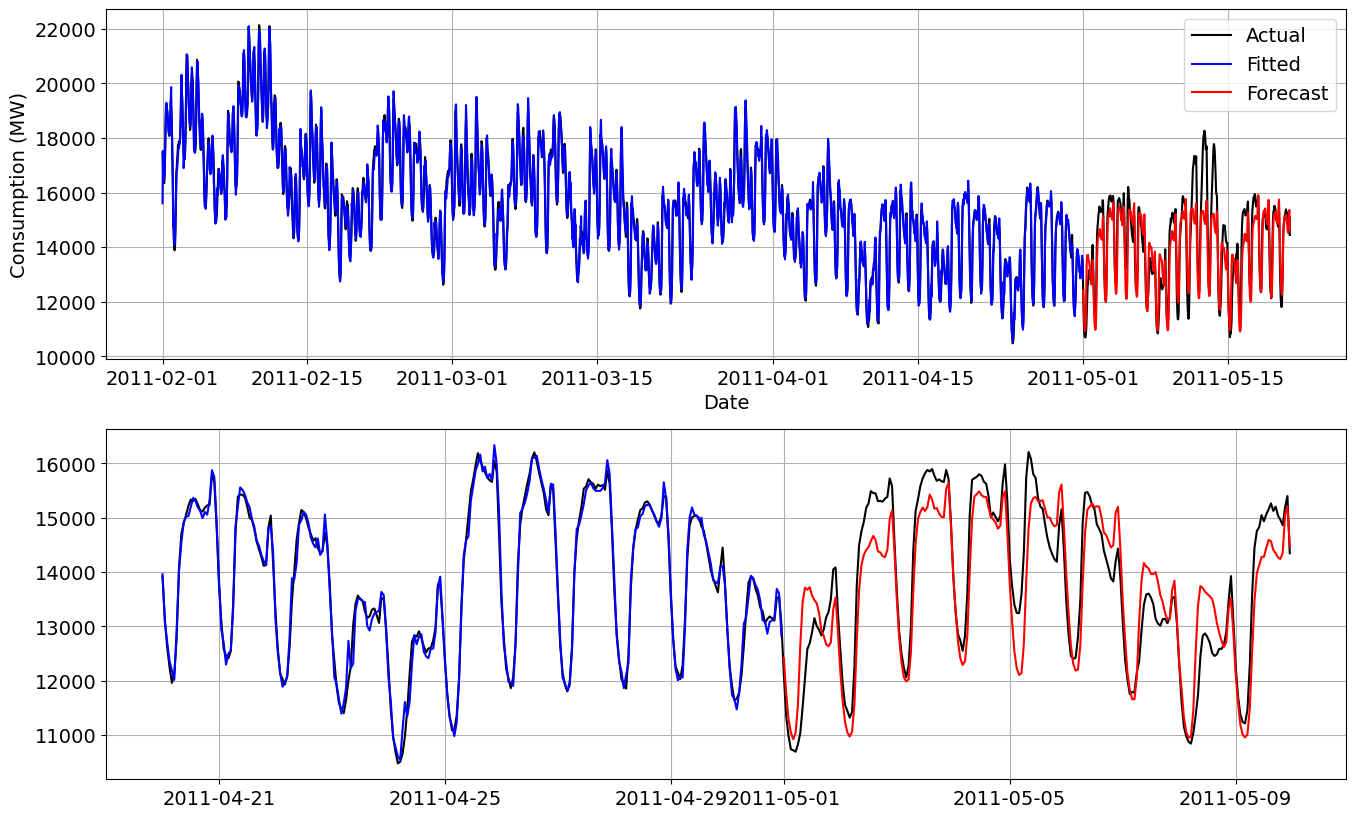

In [15]:
plt.rcParams.update({"font.size": 14})
fig, (ax1, ax2) = plt.subplots(2, figsize=(16, 10), dpi=100)

# observed data
ax1.plot(df.index, df.energy, color="k", label="Actual")

# fitted values
ax1.plot(df.index, df.bats_fit, color="b", label="Fitted")

# forecasted values
ax1.plot(df.index, df.bats_forecast, color="r", label="Forecast")

# set artists
ax1.set_xlabel("Date")
ax1.set_ylabel("Consumption (MW)")
ax1.grid()
ax1.legend()

# second plot - zoom to 10 days
df_zoom = df[
    (df.Datetime >= "2011-04-20 00:00:00") & (df.Datetime < "2011-05-10 00:00:00")
]

# observed data
ax2.plot(df_zoom.index, df_zoom.energy, color="k", label="Actual")

# fitted values
ax2.plot(df_zoom.index, df_zoom.bats_fit, color="b", label="Fitted")

# forecasted values
ax2.plot(df_zoom.index, df_zoom.bats_forecast, color="r", label="Forecast")

# set artists
ax1.set_xlabel("Date")
ax1.set_ylabel("Consumption (MW)")
ax2.grid()

plt.show()

In [16]:
tbats_estimator = TBATS(
    seasonal_periods=[24, 169],
    use_arma_errors=True,  # consider ARMA
    use_box_cox=True,  # consider Box-Cox transformation
    use_damped_trend=False,  # no damping
    use_trend=False,  # no trend
    n_jobs=1,  # number of parallel jobs
)
tbats_model = tbats_estimator.fit(X_train)

In [17]:
with open("tbats_model.pkl", "wb") as f:
    pickle.dump(tbats_model, f)


In [18]:
print(tbats_model.summary())

Use Box-Cox: True
Use trend: False
Use damped trend: False
Seasonal periods: [ 24. 169.]
Seasonal harmonics [11  7]
ARMA errors (p, q): (0, 0)
Box-Cox Lambda 0.546183
Smoothing (Alpha): 1.473954
Seasonal Parameters (Gamma): [-4.38139779e-05  3.76087534e-05 -2.20168900e-05  4.57034128e-06]
AR coefficients []
MA coefficients []
Seed vector [ 3.75786567e+02 -9.96440619e+00 -1.02120173e+00 -1.67521878e-01
 -1.20107778e+00 -9.20538112e-01  1.41650702e-01  4.04685408e-01
 -1.15136592e-01 -1.29555102e-01  4.72620531e-02  8.61340319e-02
 -7.81891116e+00 -1.22400841e+01 -2.26059835e+00  1.68296018e+00
  5.54385347e-01 -2.62054608e-01 -2.33646891e-01  1.63505258e-02
  8.18636963e-02  4.64464759e-02  8.20716422e-03  4.00810268e+00
  4.21310659e+00 -5.08121506e-02 -9.54949044e-01 -8.47239830e-01
  1.25732503e+00  4.24392363e+00  1.11682243e+01 -3.01241083e+00
 -4.56292028e-01 -3.66013563e-01  1.26744477e+00  1.26594848e-01
  9.47017235e-01]

AIC 39291.026040


In [19]:
tbats_fit = pd.DataFrame(
    tbats_model.y_hat, columns=["tbats_fit"], index=df.index[: len(X_train)]
)
df["tbats_fit"] = tbats_fit

In [20]:
tbats_fit

,tbats_fit
Datetime,
2011-02-01 00:00:00,17192.769744
2011-02-01 01:00:00,17076.792947
2011-02-01 02:00:00,16495.971846
2011-02-01 03:00:00,16348.923972
2011-02-01 04:00:00,16488.063622
...,...
2011-04-30 19:00:00,13214.549199
2011-04-30 20:00:00,13484.667966
2011-04-30 21:00:00,13266.460058


In [21]:
fc = tbats_model.forecast(steps=len(X_test))
fc = pd.DataFrame(fc, columns=["tbats_forecast"], index=df.index[len(X_train) :])
df["tbats_forecast"] = fc


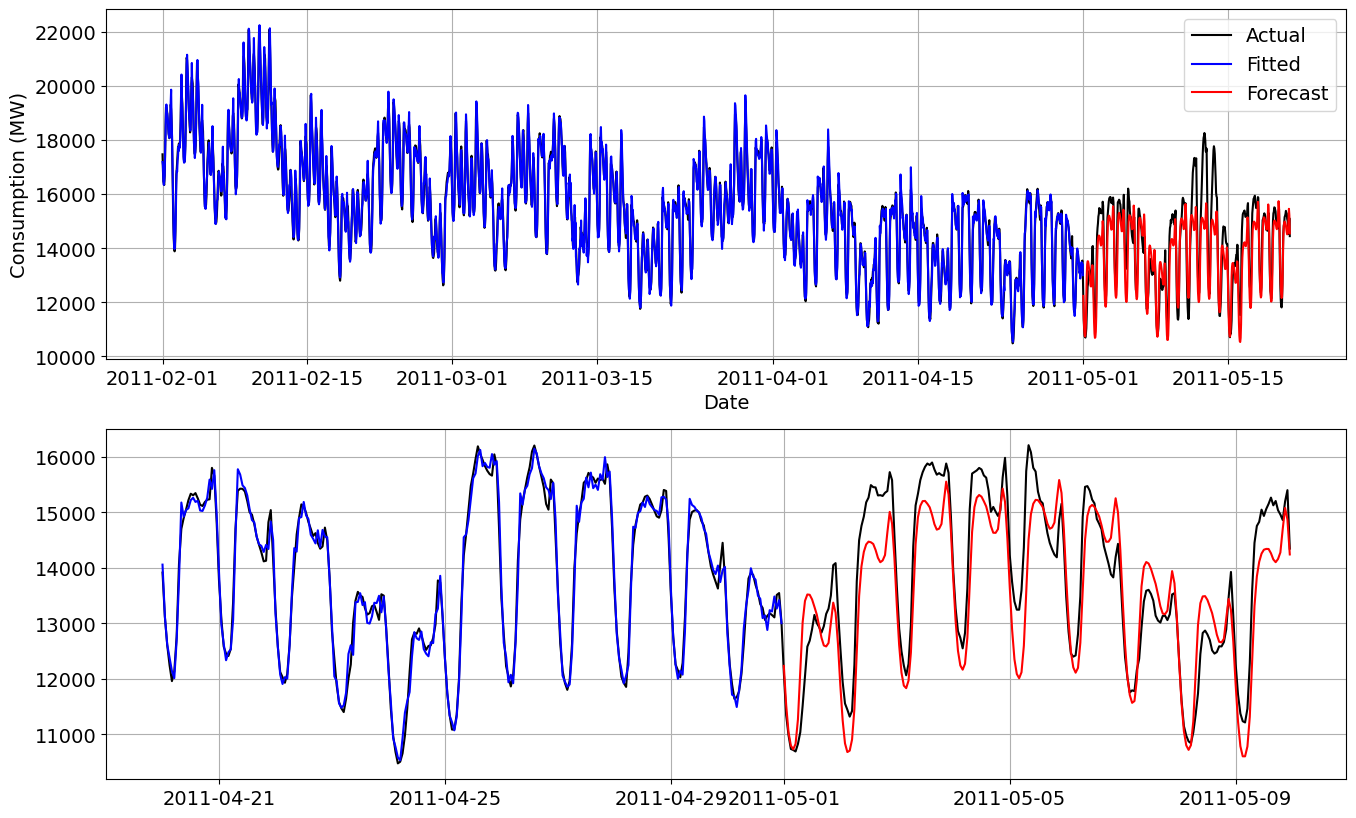

In [22]:
plt.rcParams.update({"font.size": 14})
fig, (ax1, ax2) = plt.subplots(2, figsize=(16, 10), dpi=100)

# observed data
ax1.plot(df.index, df.energy, color="k", label="Actual")

# fitted values
ax1.plot(df.index, df.tbats_fit, color="b", label="Fitted")

# forecasted values
ax1.plot(df.index, df.tbats_forecast, color="r", label="Forecast")

# set artists
ax1.set_xlabel("Date")
ax1.set_ylabel("Consumption (MW)")
ax1.grid()
ax1.legend()

# second plot - zoom to 10 days
df_zoom = df[
    (df.Datetime >= "2011-04-20 00:00:00") & (df.Datetime < "2011-05-10 00:00:00")
]

# observed data
ax2.plot(df_zoom.index, df_zoom.energy, color="k", label="Actual")

# fitted values
ax2.plot(df_zoom.index, df_zoom.tbats_fit, color="b", label="Fitted")

# forecasted values
ax2.plot(df_zoom.index, df_zoom.tbats_forecast, color="r", label="Forecast")

# set artists
ax1.set_xlabel("Date")
ax1.set_ylabel("Consumption (MW)")
ax2.grid()
plt.show()